In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [66]:
# === Cell 1. Импорты и параметры ===
import os
import ast
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse import hstack
from scipy.sparse.linalg import lsqr

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------
# Настройки данных (простые)
# -----------------------
YEAR_MIN, YEAR_MAX = 2000, 2020
VOTE_MIN = 150
TOP_N_CAST = 10

# Ограничим размерность для МНК (иначе пары взорвутся)
MAX_PEOPLE = 800
MIN_FILMS_PER_PERSON = 4
MIN_PAIR_COUNT = 2

# -----------------------
# HT параметры (простые)
# -----------------------
HT_RANK = 16
EPOCHS = 50
BATCH_SIZE = 256
LR = 3e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
VAL_SIZE = 0.2

print("CONFIG:")
print("YEAR:", YEAR_MIN, YEAR_MAX)
print("VOTE_MIN:", VOTE_MIN, "TOP_N_CAST:", TOP_N_CAST)
print("MAX_PEOPLE:", MAX_PEOPLE, "MIN_FILMS_PER_PERSON:", MIN_FILMS_PER_PERSON, "MIN_PAIR_COUNT:", MIN_PAIR_COUNT)
print("HT_RANK:", HT_RANK, "EPOCHS:", EPOCHS, "LR:", LR)


CONFIG:
YEAR: 2000 2020
VOTE_MIN: 150 TOP_N_CAST: 10
MAX_PEOPLE: 800 MIN_FILMS_PER_PERSON: 4 MIN_PAIR_COUNT: 2
HT_RANK: 16 EPOCHS: 50 LR: 0.003


In [67]:
# === Cell 2. Загрузка датасета ===

# Укажи путь к папке, где лежат movies_metadata.csv и credits.csv
# PATH = "/path/to/the-movies-dataset"
CANDIDATE_PATHS = [
    ".",  # если рядом
    "/kaggle/input/the-movies-dataset",
    "/kaggle/input/movies-dataset",
]
PATH = None
for p in CANDIDATE_PATHS:
    if os.path.exists(os.path.join(p, "movies_metadata.csv")) and os.path.exists(os.path.join(p, "credits.csv")):
        PATH = p
        break
assert PATH is not None, "Не найден movies_metadata.csv / credits.csv. Укажи PATH вручную."

movies = pd.read_csv(os.path.join(PATH, "movies_metadata.csv"), low_memory=False)
credits = pd.read_csv(os.path.join(PATH, "credits.csv"))

# Приводим id к числу
movies["id"] = pd.to_numeric(movies["id"], errors="coerce")
credits["id"] = pd.to_numeric(credits["id"], errors="coerce")

df = movies.merge(credits, on="id", how="inner")

# Приводим нужные поля
df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce")
df["vote_count"] = pd.to_numeric(df["vote_count"], errors="coerce")

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

print("Merged df:", df.shape)
print(df[["title", "vote_average", "vote_count", "release_date", "year"]].head(3))


Merged df: (45538, 27)
              title  vote_average  vote_count release_date    year
0         Toy Story           7.7      5415.0   1995-10-30  1995.0
1           Jumanji           6.9      2413.0   1995-12-15  1995.0
2  Grumpier Old Men           6.5        92.0   1995-12-22  1995.0


In [68]:
# === Cell 3. Парсинг genres/cast/crew ===

def safe_parse_json_list(x):
    try:
        if pd.isna(x):
            return []
        return ast.literal_eval(x)
    except Exception:
        return []

def get_main_genre(genres_str):
    arr = safe_parse_json_list(genres_str)
    if len(arr) == 0:
        return "Unknown"
    nm = arr[0].get("name", "Unknown")
    return nm if isinstance(nm, str) and nm else "Unknown"

def extract_director(crew_str):
    arr = safe_parse_json_list(crew_str)
    for it in arr:
        if it.get("job") == "Director":
            try:
                return int(it.get("id")), it.get("name")
            except Exception:
                return None, None
    return None, None

def extract_top_cast(cast_str, top_n=10):
    arr = safe_parse_json_list(cast_str)
    # сортируем по order
    for it in arr:
        if "order" not in it or pd.isna(it["order"]):
            it["order"] = 10**9
    arr = sorted(arr, key=lambda z: z.get("order", 10**9))

    out = []
    for it in arr[:top_n]:
        try:
            out.append((int(it.get("id")), it.get("name")))
        except Exception:
            pass
    return out

df["main_genre"] = df["genres"].apply(get_main_genre)
df["director"] = df["crew"].apply(extract_director)
df["cast_top"] = df["cast"].apply(lambda x: extract_top_cast(x, top_n=TOP_N_CAST))

# Фильтруем по году и vote_count
df = df[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df[df["vote_count"] >= VOTE_MIN]
df = df.dropna(subset=["vote_average", "vote_count"])

# Убираем фильмы без режиссёра и без актёров
df = df[df["director"].apply(lambda x: x[0] is not None)]
df = df[df["cast_top"].apply(lambda x: len(x) >= 2)]

print("After basic filters:", df.shape)
print(df[["title","year","main_genre","vote_average","vote_count"]].head(5))
print("\nExample director+cast:")
ex = df.iloc[0]
print("Title:", ex["title"])
print("Director:", ex["director"])
print("Cast top:", ex["cast_top"][:5])


After basic filters: (3332, 30)
                     title    year main_genre  vote_average  vote_count
3160              Scream 3  2000.0     Horror           5.7       749.0
3172             The Beach  2000.0      Drama           6.3      1271.0
3185           Boiler Room  2000.0      Crime           6.5       202.0
3187           Pitch Black  2000.0   Thriller           6.7      1812.0
3188  The Whole Nine Yards  2000.0     Comedy           6.3       540.0

Example director+cast:
Title: Scream 3
Director: (5140, 'Wes Craven')
Cast top: [(15234, 'David Arquette'), (9206, 'Neve Campbell'), (14405, 'Courteney Cox'), (18352, 'Patrick Dempsey'), (35595, 'Scott Foley')]


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


In [69]:
# === Cell 4. Участники фильма + цель y ===

def build_participants(row):
    d_id, d_name = row["director"]
    lst = [(d_id, d_name)] + row["cast_top"]
    # уникализируем по pid
    seen = set()
    uniq = []
    for pid, pname in lst:
        if pid not in seen:
            seen.add(pid)
            uniq.append((pid, pname))
    return uniq

df["participants"] = df.apply(build_participants, axis=1)

# y = vote_average (простая цель)
df["y"] = df["vote_average"].astype(float)

print("Sample participants:")
for i in range(3):
    row = df.iloc[i]
    print("\n-", row["title"], row["year"], row["main_genre"], "y=", row["y"])
    print("  participants:", [p[1] for p in row["participants"][:6]], "...")


Sample participants:

- Scream 3 2000.0 Horror y= 5.7
  participants: ['Wes Craven', 'David Arquette', 'Neve Campbell', 'Courteney Cox', 'Patrick Dempsey', 'Scott Foley'] ...

- The Beach 2000.0 Drama y= 6.3
  participants: ['Danny Boyle', 'Leonardo DiCaprio', 'Guillaume Canet', 'Tilda Swinton', 'Virginie Ledoyen', 'Staffan Kihlbom'] ...

- Boiler Room 2000.0 Crime y= 6.5
  participants: ['Ben Younger', 'Giovanni Ribisi', 'Vin Diesel', 'Nia Long', 'Tom Everett Scott', 'Ben Affleck'] ...


In [70]:
# === Cell 5. Отбор людей и пар (чтобы МНК был адекватным) ===

# частоты людей
person_freq = Counter()
for plist in df["participants"]:
    for pid, _ in plist:
        person_freq[pid] += 1

# кандидаты: минимум фильмов
candidates = [pid for pid, cnt in person_freq.items() if cnt >= MIN_FILMS_PER_PERSON]
candidates = sorted(candidates, key=lambda pid: person_freq[pid], reverse=True)[:MAX_PEOPLE]
candidate_set = set(candidates)

print("People before filter:", len(person_freq))
print("People after filter:", len(candidate_set))
print("Top-5 people by freq:", [(pid, person_freq[pid]) for pid in candidates[:5]])

# фильтруем фильмы: хотя бы 2 участника из candidate_set
def film_ok(plist):
    ids = [pid for pid, _ in plist if pid in candidate_set]
    return len(ids) >= 2

df = df[df["participants"].apply(film_ok)].copy()
print("Films after filter:", df.shape)

# пересчитываем частоты и пары
person_freq2 = Counter()
pair_freq = Counter()

for plist in df["participants"]:
    ids = sorted({pid for pid, _ in plist if pid in candidate_set})
    for pid in ids:
        person_freq2[pid] += 1
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            pair_freq[(ids[i], ids[j])] += 1

good_pairs = {p for p, c in pair_freq.items() if c >= MIN_PAIR_COUNT}

print("Final people:", len(person_freq2))
print("Pairs total:", len(pair_freq), "Pairs kept:", len(good_pairs))

# индексации
people = sorted(person_freq2.keys())
pid2idx = {pid: i for i, pid in enumerate(people)}
idx2pid = {i: pid for pid, i in pid2idx.items()}

pairs = sorted(list(good_pairs))
pair2idx = {p: i for i, p in enumerate(pairs)}

# имена
pid2name = {}
for plist in df["participants"]:
    for pid, name in plist:
        if pid in pid2idx and pid not in pid2name:
            pid2name[pid] = name

print("\nCheck mappings:")
print("P =", len(people), "M =", len(pairs))
print("Example person:", people[0], pid2name.get(people[0]))
print("Example pair:", pairs[0], pid2name.get(pairs[0][0]), "+", pid2name.get(pairs[0][1]))


People before filter: 15329
People after filter: 800
Top-5 people by freq: [(2231, 43), (192, 37), (1892, 36), (887, 34), (13242, 34)]
Films after filter: (2412, 32)
Final people: 800
Pairs total: 19703 Pairs kept: 2201

Check mappings:
P = 800 M = 2201
Example person: 3 Harrison Ford
Example pair: (18, 2372) Brad Garrett + Ron Perlman


In [71]:
# === Cell 6. Сборка X_ind и X_pair ===

n = len(df)
P = len(people)
M = len(pairs)

rows_ind, cols_ind, data_ind = [], [], []
rows_pair, cols_pair, data_pair = [], [], []

y = df["y"].values.astype(np.float64)

for row_i, plist in enumerate(df["participants"]):
    ids = sorted({pid for pid, _ in plist if pid in pid2idx})

    # индивиды
    for pid in ids:
        rows_ind.append(row_i)
        cols_ind.append(pid2idx[pid])
        data_ind.append(1.0)

    # пары
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            p = (ids[i], ids[j])
            if p in pair2idx:
                rows_pair.append(row_i)
                cols_pair.append(pair2idx[p])
                data_pair.append(1.0)

X_ind = csr_matrix((data_ind, (rows_ind, cols_ind)), shape=(n, P))
X_pair = csr_matrix((data_pair, (rows_pair, cols_pair)), shape=(n, M))

print("Shapes:")
print("X_ind:", X_ind.shape, "nnz:", X_ind.nnz) 
print("X_pair:", X_pair.shape, "nnz:", X_pair.nnz)
print("y:", y.shape, "y sample:", y[:5])


Shapes:
X_ind: (2412, 800) nnz: 10717
X_pair: (2412, 2201) nnz: 5498
y: (2412,) y sample: [5.7 6.3 6.5 6.7 6.3]


In [72]:
# === Cell 7. OLS с интерсептом ===

from scipy.sparse import csr_matrix, hstack

# Число наблюдений
n = X_ind.shape[0]

# Столбец единиц для интерсепта
ones = csr_matrix(np.ones((n, 1)))

# Итоговая матрица: [1 | X_ind | X_pair]
X = hstack([ones, X_ind, X_pair]).tocsr()

print("X shape with intercept:", X.shape)

# Решаем МНК
res = lsqr(X, y, atol=1e-7, btol=1e-7, iter_lim=500)
beta = res[0]

# Раскладываем параметры
intercept = beta[0]
a_hat = beta[1:1+P]
b_hat = beta[1+P:]

#print("LSQR iters:", res[2], "residual norm:", res[3])
print("Intercept:", intercept)

# Предсказания и ошибка на обучении
y_hat = X @ beta
mse = float(np.mean((y - y_hat)**2))

#print("Train MSE:", mse)

# Быстрый sanity-check
print("\nSanity check (5 films):")
tmp = df[["title","year","main_genre","y"]].head(5).copy()
tmp["y_hat"] = y_hat[:5]
tmp["err"] = tmp["y"] - tmp["y_hat"]
tmp


X shape with intercept: (2412, 3002)
Intercept: 6.290104985976131

Sanity check (5 films):


,title,year,main_genre,y,y_hat,err
3160,Scream 3,2000.0,Horror,5.7,5.472145,0.227855
3172,The Beach,2000.0,Drama,6.3,6.539934,-0.239934
3185,Boiler Room,2000.0,Crime,6.5,6.160792,0.339208
3187,Pitch Black,2000.0,Thriller,6.7,6.219033,0.480967
3188,The Whole Nine Yards,2000.0,Comedy,6.3,6.300109,-0.000109


In [73]:
# === Cell 8. TOP individuals / pairs (OLS) ===

def top_individuals(a, k=10):
    idx = np.argsort(-a)[:k]
    return [(pid2name.get(idx2pid[i], str(idx2pid[i])), float(a[i])) for i in idx]

def top_pairs(b, k=10):
    idx = np.argsort(-b)[:k]
    out = []
    for j in idx:
        p = pairs[j]
        out.append((pid2name.get(p[0], str(p[0])),
                    pid2name.get(p[1], str(p[1])),
                    float(b[j]),
                    int(pair_freq[p])))
    return out

print("TOP-10 individuals by a_i:")
for nm, val in top_individuals(a_hat, 10):
    print(f"{nm:35s} a={val:+.4f}")

print("\nTOP-10 pairs by b_ij:")
for n1, n2, val, cnt in top_pairs(b_hat, 10):
    print(f"{n1:25s} + {n2:25s} b={val:+.4f}  (cofilms={cnt})")


TOP-10 individuals by a_i:
Mae Whitman                         a=+2.5347
Imelda Staunton                     a=+2.1976
John Lithgow                        a=+2.1951
Ron Howard                          a=+2.1749
Jared Leto                          a=+2.0348
Ridley Scott                        a=+1.9650
Rutger Hauer                        a=+1.8292
Ann Dowd                            a=+1.8155
Jamie Foxx                          a=+1.7540
Abbie Cornish                       a=+1.6705

TOP-10 pairs by b_ij:
Helena Bonham Carter      + Brendan Gleeson           b=+7.1533  (cofilms=2)
Geoffrey Rush             + Tom Hollander             b=+6.9944  (cofilms=2)
Bruce Willis              + Mary Elizabeth Winstead   b=+6.6499  (cofilms=2)
Tom Hanks                 + Amy Adams                 b=+5.4449  (cofilms=2)
Sean Penn                 + Marcia Gay Harden         b=+5.3061  (cofilms=2)
Jeffrey Wright            + Daniel Craig              b=+5.0222  (cofilms=3)
Clive Owen                + 

Error percentiles: -0.44913923074843287 0.4488582162182604


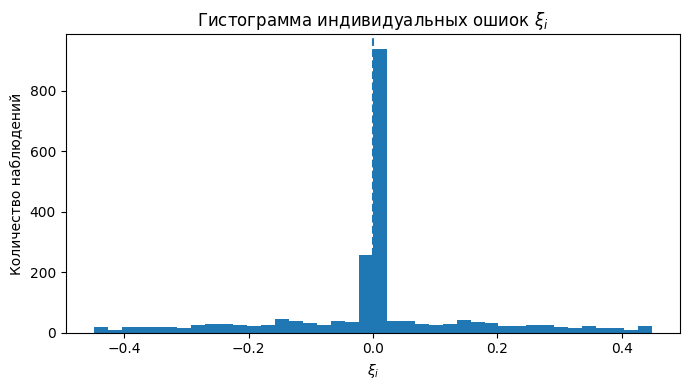

In [74]:
# === Cell 9. Ошибки OLS ===
err = (y - y_hat)

p1, p99 = np.percentile(err, [5, 95])
err_trim = err[(err >= p1) & (err <= p99)]

print("Error percentiles:", p1, p99)
#print("Trimmed size:", len(err_trim), "of", len(err))

plt.figure(figsize=(7,4))
plt.hist(err_trim, bins=40)
plt.axvline(0, linestyle="--")
plt.title(r"Гистограмма индивидуальных ошиок $\xi_i$")
plt.xlabel(r"$\xi_i$")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()


In [75]:
# === Cell 10. Жадный подбор состава по OLS + разбор вкладов ===

def ols_score_cast(ids):
    """score = sum a_i + sum b_ij по тем, кто есть в словарях"""
    ids_u = [pid for pid in dict.fromkeys(ids)]  # сохранить порядок
    ids_known = [pid for pid in ids_u if pid in pid2idx]
    s = 0.0
    for pid in ids_known:
        s += float(a_hat[pid2idx[pid]])
    ids_sorted = sorted(ids_known)
    for i in range(len(ids_sorted)):
        for j in range(i+1, len(ids_sorted)):
            p = (ids_sorted[i], ids_sorted[j])
            if p in pair2idx:
                s += float(b_hat[pair2idx[p]])
    return float(s)

def greedy_cast_search_ols(director_pid, k=5, actor_pool=None):
    if actor_pool is None:
        # пул актёров: топ по индивидуальному эффекту
        actor_pool = [idx2pid[i] for i in np.argsort(-a_hat)[:250]]

    chosen = [director_pid]
    remaining = [pid for pid in actor_pool if pid != director_pid]

    for step in range(k):
        best_pid, best_val = None, -1e18
        for pid in remaining:
            val = ols_score_cast(chosen + [pid])
            if val > best_val:
                best_val = val
                best_pid = pid
        chosen.append(best_pid)
        remaining.remove(best_pid)

        print(f"Step {step+1}: added {pid2name.get(best_pid, str(best_pid))}, score={best_val:+.4f}")

    return chosen, ols_score_cast(chosen)

def print_ols_breakdown(cast_ids):
    print("\n=== OLS breakdown for chosen cast ===")
    print("Cast:")
    for pid in cast_ids:
        print(" -", pid2name.get(pid, str(pid)))

    print("\nIndividual effects a_i:")
    a_sum = 0.0
    for pid in cast_ids:
        val = float(a_hat[pid2idx[pid]]) if pid in pid2idx else 0.0
        a_sum += val
        print(f"{pid2name.get(pid, str(pid)):35s} a={val:+.4f}")
    print(f"SUM(a) = {a_sum:+.4f}")

    print("\nPair effects b_ij:")
    b_sum = 0.0
    ids_known = [pid for pid in cast_ids if pid in pid2idx]
    ids_sorted = sorted(ids_known)
    for i in range(len(ids_sorted)):
        for j in range(i+1, len(ids_sorted)):
            p = (ids_sorted[i], ids_sorted[j])
            val = float(b_hat[pair2idx[p]]) if p in pair2idx else 0.0
            b_sum += val
            print(f"{pid2name.get(p[0], str(p[0])):25s} + {pid2name.get(p[1], str(p[1])):25s} b={val:+.4f}")
    print(f"SUM(b) = {b_sum:+.4f}")

    print(f"\nTOTAL OLS score = {a_sum + b_sum:+.4f}")

# выберем директора: топ по a_hat среди всех людей (просто демонстрация)
best_dir_pid = idx2pid[int(np.argmax(a_hat))]
print("Chosen director candidate:", pid2name.get(best_dir_pid, str(best_dir_pid)))

cast_ols, score_ols = greedy_cast_search_ols(best_dir_pid, k=5)
print("\nFinal OLS cast score:", score_ols)
print_ols_breakdown(cast_ols)


Chosen director candidate: Mae Whitman
Step 1: added Imelda Staunton, score=+4.7323
Step 2: added John Lithgow, score=+6.9274
Step 3: added Ron Howard, score=+9.1024
Step 4: added Jared Leto, score=+11.1372
Step 5: added Ridley Scott, score=+13.1022

Final OLS cast score: 13.10215241306986

=== OLS breakdown for chosen cast ===
Cast:
 - Mae Whitman
 - Imelda Staunton
 - John Lithgow
 - Ron Howard
 - Jared Leto
 - Ridley Scott

Individual effects a_i:
Mae Whitman                         a=+2.5347
Imelda Staunton                     a=+2.1976
John Lithgow                        a=+2.1951
Ron Howard                          a=+2.1749
Jared Leto                          a=+2.0348
Ridley Scott                        a=+1.9650
SUM(a) = +13.1022

Pair effects b_ij:
Ridley Scott              + Ron Howard                b=+0.0000
Ridley Scott              + Jared Leto                b=+0.0000
Ridley Scott              + Imelda Staunton           b=+0.0000
Ridley Scott              + John Lithgo

In [76]:
# === Cell 11. HT dataset: director + actor_1..actor_TOP_N_CAST (categorical indices) ===

# роли (измерения тензора)
role_names = ["director"] + [f"actor_{i+1}" for i in range(TOP_N_CAST)]
D = len(role_names)

# Собираем частоты отдельно для режиссёров и актёров
dir_freq = Counter()
actor_freq = Counter()

for _, row in df.iterrows():
    d_id, _ = row["director"]
    dir_freq[d_id] += 1
    for pid, _ in row["cast_top"]:
        actor_freq[pid] += 1

MAX_DIRS = 300
MAX_ACTORS = 500

top_dirs = [pid for pid, _ in dir_freq.most_common(MAX_DIRS)]
top_actors = [pid for pid, _ in actor_freq.most_common(MAX_ACTORS)]

# индексация: 0 = OTHER, 1.. = конкретный
dir2cat = {pid: i+1 for i, pid in enumerate(top_dirs)}
act2cat = {pid: i+1 for i, pid in enumerate(top_actors)}

cardinalities = [1 + len(top_dirs)] + [1 + len(top_actors)] * TOP_N_CAST

print("HT dims D =", D)
print("Cardinalities:", cardinalities[:3], "...", "(total dims:", len(cardinalities), ")")

# X_idx: (n, D)
X_idx = np.zeros((len(df), D), dtype=np.int64)
y_ht = df["y"].values.astype(np.float32)

for r, (_, row) in enumerate(df.iterrows()):
    d_id, _ = row["director"]
    X_idx[r, 0] = dir2cat.get(d_id, 0)

    cast = row["cast_top"][:TOP_N_CAST]
    for j in range(TOP_N_CAST):
        if j < len(cast):
            pid, _ = cast[j]
            X_idx[r, 1+j] = act2cat.get(pid, 0)
        else:
            X_idx[r, 1+j] = 0

print("X_idx shape:", X_idx.shape)
print("Sample X_idx rows (first 3):")
print(X_idx[:3])
print("Sample y (first 5):", y_ht[:5])


HT dims D = 11
Cardinalities: [301, 501, 501] ... (total dims: 11 )
X_idx shape: (2412, 11)
Sample X_idx rows (first 3):
[[106   0   0   0   0   0   0   0   0 255   0]
 [ 26 219   0  92   0   0   0   0   0   0   0]
 [188 115  93   0   0  40   0   0   0   0   0]]
Sample y (first 5): [5.7 6.3 6.5 6.7 6.3]


In [77]:
# === Cell 12. Sanity-check HT на синтетике ===

def make_synth(n_samples=4000, cards=[5, 6, 7], seed=0):
    rng = np.random.default_rng(seed)
    X = np.stack([rng.integers(0, c, size=n_samples) for c in cards], axis=1)
    y = X.sum(axis=1).astype(np.float32)  # простая функция
    return X, y

X_s, y_s = make_synth()
print("Synth shapes:", X_s.shape, y_s.shape)
print("Synth sample:", X_s[:5], y_s[:5])


Synth shapes: (4000, 3) (4000,)
Synth sample: [[4 2 3]
 [3 5 4]
 [2 3 4]
 [1 0 3]
 [1 4 6]] [ 9. 12.  9.  4. 11.]


In [83]:
# === Cell 13. HT (почти как SimpleHT) ===
import torch
import torch.nn as nn

class HTNode:
    """Узел HT дерева (как в SimpleHT): хранит ядро и рекурсивно вычисляет значение."""
    def __init__(self, rank, shapes, tensor_index, parent=None, node_type=None, dtype=torch.float32, device='cpu'):
        self.type = node_type
        self.tensor_index = tensor_index          # список индексов измерений (для поддерева)
        self.rank = rank
        self.parent = parent
        self.shapes = shapes                      # список cardinalities для поддерева
        self.dtype = dtype
        self.device = device
        self.childrens = []
        self.core = None                          # nn.Parameter будет присвоен позже

    def build_childrens(self):
        """Строим сбалансированное бинарное дерево по shapes."""
        n = len(self.shapes)
        if n == 1:
            self.type = 'leaf'
            self.shapes = int(self.shapes[0])        # cardinality листа
            self.tensor_index = int(self.tensor_index[0])
            self.childrens = []
            return

        if self.type is None:
            self.type = 'node'

        left_n = (n + 1) // 2
        self.childrens = [
            HTNode(rank=self.rank, shapes=self.shapes[:left_n], tensor_index=self.tensor_index[:left_n],
                   parent=self, dtype=self.dtype, device=self.device),
            HTNode(rank=self.rank, shapes=self.shapes[left_n:], tensor_index=self.tensor_index[left_n:],
                   parent=self, dtype=self.dtype, device=self.device),
        ]
        for node in self.childrens:
            node.build_childrens()

    def init_core(self, rand_func='xavier'):
        """Инициализация ядра в зависимости от типа узла."""
        if self.type == 'leaf':
            # (cardinality, rank)
            core = torch.empty(self.shapes, self.rank, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)
        elif self.type == 'node':
            # (rank, rank, rank)
            core = torch.empty(self.rank, self.rank, self.rank, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)
        else:
            # root: (rank, rank, 1)
            core = torch.empty(self.rank, self.rank, 1, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)

        self.core = nn.Parameter(core)
        return self.core

    def init_core_all(self, cores):
        """Рекурсивно инициализируем ядра всего дерева и складываем в список параметров."""
        cores.append(self.init_core())
        for node in self.childrens:
            node.init_core_all(cores)

    def evaluate(self, indices):
        """Рекурсивное вычисление: leaf -> embedding; node/root -> einsum."""
        if self.type == 'leaf':
            idx = indices[:, self.tensor_index]      # (bs,)
            return self.core[idx, :]                 # (bs, rank)

        # Для внутренних узлов: вычисляем детей, потом сворачиваем
        left = self.childrens[0].evaluate(indices)   # (bs, rank)
        right = self.childrens[1].evaluate(indices)  # (bs, rank)

        # einsum: (bs,a) * (bs,b) * (a,b,c) -> (bs,c)
        out = torch.einsum('ka,kb,abc->kc', left, right, self.core)
        # ВНИМАНИЕ: чтобы не путаться, лучше так (явно разные буквы):
        # out = torch.einsum('ka,kb,abc->kc', left, right, self.core)

        return out


class HTDecomposition(nn.Module):
    """HT-разложение: строит дерево и умеет forward."""
    def __init__(self, shapes, rank=16, dtype=torch.float32, device='cpu'):
        super().__init__()
        self.shapes = tuple(int(s) for s in shapes)
        self.dim = len(self.shapes)
        self.rank = rank
        self.dtype = dtype
        self.device = device

        self.root, cores = self._build_tree()
        self.cores = nn.ParameterList(cores)  # важно, чтобы параметры увидел оптимизатор

    def _build_tree(self):
        root = HTNode(node_type='root', rank=self.rank, shapes=list(self.shapes),
                      tensor_index=list(range(self.dim)), dtype=self.dtype, device=self.device)
        root.build_childrens()

        cores = []
        root.init_core_all(cores)
        return root, cores

    def forward(self, idx):
        # idx: (bs, dim) long
        return self.root.evaluate(idx).squeeze(-1)


# Быстрый print-диагностика размеров дерева (не идеально, но полезно)
def count_params(model):
    return sum(p.numel() for p in model.parameters())

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

model_ht = HTDecomposition(shapes=cardinalities, rank=HT_RANK, dtype=torch.float32, device=device).to(device)
print("HT model created. dim =", model_ht.dim, "rank =", model_ht.rank)
print("Total parameters:", count_params(model_ht))


Device: cpu
HT model created. dim = 11 rank = 16
Total parameters: 122096


In [84]:
# === Cell 14. Обучение SimpleHT (HTDecomposition) на реальных данных ===

import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

# --- 1) Train/Val split ---
X_tr, X_va, y_tr, y_va = train_test_split(
    X_idx, y_ht, test_size=VAL_SIZE, random_state=SEED
)

print("Train size:", X_tr.shape, "Val size:", X_va.shape)
print("X_tr sample rows:\n", X_tr[:3])
print("y_tr sample:", y_tr[:10])

# --- 2) Нормализация y (для устойчивости HT) ---
y_mean = float(y_tr.mean())
y_std = float(y_tr.std() + 1e-6)

y_tr_n = (y_tr - y_mean) / y_std
y_va_n = (y_va - y_mean) / y_std

print("\nTarget normalization:")
print("y_mean =", y_mean, "y_std =", y_std)
print("y_tr_n sample:", y_tr_n[:10])

# --- 3) Создание модели (SimpleHT) ---
# HTDecomposition должен быть объявлен в ячейке 13
model_ht = HTDecomposition(shapes=cardinalities, rank=HT_RANK, dtype=torch.float32, device=device).to(device)

# Промежуточно: сколько параметров
total_params = sum(p.numel() for p in model_ht.parameters())
print("\nHT model summary:")
print("dim =", model_ht.dim, "rank =", model_ht.rank)
print("total parameters =", total_params)

# --- 4) Оптимизатор + план обучения ---
optimizer = torch.optim.AdamW(model_ht.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def batch_iter(X, y, batch_size, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    for st in range(0, len(X), batch_size):
        j = idx[st:st+batch_size]
        yield X[j], y[j]

def mse_loss(pred, target):
    return torch.mean((pred - target) ** 2)

# --- 5) Тренировочный цикл ---
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    model_ht.train()
    train_losses = []

    for xb_np, yb_np in batch_iter(X_tr, y_tr_n, batch_size=BATCH_SIZE, seed=SEED + epoch):
        xb = torch.tensor(xb_np, dtype=torch.long, device=device)         # (bs, D)
        yb = torch.tensor(yb_np, dtype=torch.float32, device=device)      # (bs,)

        optimizer.zero_grad(set_to_none=True)
        pred = model_ht(xb)                                               # (bs,)
        loss = mse_loss(pred, yb)
        loss.backward()

        # grad clipping (стабилизация)
        grad_norm = torch.nn.utils.clip_grad_norm_(model_ht.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(float(loss.detach().cpu().item()))

    # --- Val ---
    model_ht.eval()
    with torch.no_grad():
        xb = torch.tensor(X_va, dtype=torch.long, device=device)
        yb = torch.tensor(y_va_n, dtype=torch.float32, device=device)
        pred = model_ht(xb)
        val_loss = float(mse_loss(pred, yb).cpu().item())

    scheduler.step()

    # лог каждые N эпох
    if epoch == 1 or epoch % 5 == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:03d} | train MSE={np.mean(train_losses):.4f} | val MSE={val_loss:.4f} | "
              f"grad_norm={float(grad_norm):.3f} | lr={lr_now:.2e}")

    # сохранение лучшего
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model_ht.state_dict().items()}

# --- 6) Загружаем лучший state ---
model_ht.load_state_dict(best_state)
model_ht.eval()

print("\nTraining done.")
print("Best val MSE (normalized) =", best_val)

# --- 7) Проверка: несколько предсказаний на val в исходной шкале ---
with torch.no_grad():
    xb = torch.tensor(X_va[:10], dtype=torch.long, device=device)
    pred_n = model_ht(xb).cpu().numpy()
pred = pred_n * y_std + y_mean

print("\nVAL sample predictions (first 10):")
for i in range(10):
    print(f"y_true={float(y_va[i]):.3f} | y_pred={float(pred[i]):.3f} | diff={float(y_va[i]-pred[i]):+.3f}")


Device: cpu
Train size: (1929, 11) Val size: (483, 11)
X_tr sample rows:
 [[  0   0   0  82   0   0   0   0 297 480   0]
 [  0 158 402 213 479   0  35   0   0   0   0]
 [104   4  76   0   0 237   0   0   0   0   0]]
y_tr sample: [5.5 6.8 6.9 5.1 6.7 6.6 5.7 5.7 6.2 6.4]

Target normalization:
y_mean = 6.310626983642578 y_std = 0.749167488647461
y_tr_n sample: [-1.0820371   0.6532227   0.78670406 -1.6159631   0.5197407   0.38625932
 -0.8150743  -0.8150743  -0.14766681  0.11929657]

HT model summary:
dim = 11 rank = 16
total parameters = 122096
Epoch 001 | train MSE=1.0125 | val MSE=0.9645 | grad_norm=0.000 | lr=3.00e-03
Epoch 005 | train MSE=0.9849 | val MSE=0.9645 | grad_norm=0.000 | lr=2.93e-03
Epoch 010 | train MSE=1.0055 | val MSE=0.9645 | grad_norm=0.000 | lr=2.71e-03
Epoch 015 | train MSE=0.9971 | val MSE=0.9645 | grad_norm=0.000 | lr=2.38e-03
Epoch 020 | train MSE=0.9977 | val MSE=0.9645 | grad_norm=0.000 | lr=1.96e-03
Epoch 025 | train MSE=0.9962 | val MSE=0.9645 | grad_norm=0.0

In [87]:
# === Cell 15. Подбор состава по HT + сравнение с OLS ===

def ht_score_cast(director_pid, actor_pids):
    """Собираем слоты director + actors и получаем предсказание vote_average"""
    x = np.zeros((1, D), dtype=np.int64)
    x[0, 0] = dir2cat.get(director_pid, 0)

    act = list(actor_pids)[:TOP_N_CAST]
    for j in range(TOP_N_CAST):
        x[0, 1+j] = act2cat.get(act[j], 0) if j < len(act) else 0

    pred_n = model_ht.predict(x, device=device)[0]
    pred = float(pred_n * y_sd + y_mu)
    return pred

def greedy_cast_search_ht(director_pid, k=5, actor_pool=None):
    if actor_pool is None:
        # пул актёров: топ по частоте (просто и стабильно)
        actor_pool = [pid for pid, _ in actor_freq.most_common(250)]

    chosen = []
    remaining = [pid for pid in actor_pool if pid != director_pid]

    for step in range(k):
        best_pid, best_val = None, -1e18
        for pid in remaining:
            val = ht_score_cast(director_pid, chosen + [pid])
            if val > best_val:
                best_val = val
                best_pid = pid
        chosen.append(best_pid)
        remaining.remove(best_pid)
        print(f"HT Step {step+1}: added {pid2name.get(best_pid, str(best_pid))}, pred={best_val:.3f}")

    final_pred = ht_score_cast(director_pid, chosen)
    return [director_pid] + chosen, final_pred

# Для сравнения возьмём несколько кандидатов режиссёров (топ по частоте)
top_directors = [pid for pid, _ in dir_freq.most_common(50)]
actor_pool_simple = [pid for pid, _ in actor_freq.most_common(250)]

print("Top directors sample:", [(pid2name.get(d, str(d)), dir_freq[d]) for d in top_directors[:5]])

best_ols = None
best_ht = None

print("\n=== Searching best OLS cast among top directors ===")
for dpid in top_directors[:20]:  # чтобы не было долго, начнём с 20
    cast_ids, score = greedy_cast_search_ols(dpid, k=5, actor_pool=actor_pool_simple)
    if best_ols is None or score > best_ols["score"]:
        best_ols = {"director": dpid, "cast": cast_ids, "score": score}

print("\n=== Searching best HT cast among top directors ===")
for dpid in top_directors[:20]:
    cast_ids, pred = greedy_cast_search_ht(dpid, k=5, actor_pool=actor_pool_simple)
    if best_ht is None or pred > best_ht["pred"]:
        best_ht = {"director": dpid, "cast": cast_ids, "pred": pred}

print("\n================ RESULT ================")
print("BEST OLS cast (score = sum a_i + sum b_ij):", best_ols["score"])
for pid in best_ols["cast"]:
    print(" -", pid2name.get(pid, str(pid)))

print("\nBEST HT cast (predicted vote_average):", best_ht["pred"])
for pid in best_ht["cast"]:
    print(" -", pid2name.get(pid, str(pid)))

print("\nOLS breakdown for best OLS cast:")
print_ols_breakdown(best_ols["cast"])


Top directors sample: [('Woody Allen', 15), ('Steven Soderbergh', 14), ('Ridley Scott', 14), ('Clint Eastwood', 13), ('Steven Spielberg', 12)]

=== Searching best OLS cast among top directors ===
Step 1: added Jamie Foxx, score=+2.0257
Step 2: added Chris Cooper, score=+3.9987
Step 3: added Scarlett Johansson, score=+5.5363
Step 4: added Anthony Mackie, score=+8.0710
Step 5: added Bill Murray, score=+10.0902
Step 1: added Matt Damon, score=+4.0755
Step 2: added Catherine Zeta-Jones, score=+7.8685
Step 3: added John Cusack, score=+9.7458
Step 4: added Brian Cox, score=+11.5455
Step 5: added Jamie Foxx, score=+13.2995
Step 1: added Jamie Foxx, score=+3.7190
Step 2: added Chris Cooper, score=+5.6920
Step 3: added Emma Thompson, score=+7.0294
Step 4: added Woody Harrelson, score=+8.2945
Step 5: added Ben Stiller, score=+9.5465
Step 1: added Jamie Foxx, score=+2.5931
Step 2: added Chris Cooper, score=+4.5662
Step 3: added Morgan Freeman, score=+6.2394
Step 4: added Radha Mitchell, score=+10

AttributeError: 'HTDecomposition' object has no attribute 'predict'